In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing tools
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Common algorithms
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
path='/content/drive/MyDrive/Datasets_Drive/Diabetes/diabetes.csv'
data=pd.read_csv(path)

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.shape

(768, 9)

In [6]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
data['Glucose'].isnull().sum()/len(data)*100

np.float64(0.0)

In [9]:
data['BloodPressure'].isnull().sum()/len(data)*100

np.float64(0.0)

In [10]:
int(data.shape[0]*0.9)

691

In [11]:
# Now we are diving dta into two forms X AND Y so X contains traing input and Y contains only Output
X=data.drop('Outcome',axis=1)
Y=data['Outcome']

In [12]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [13]:
Y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [14]:
X.var(axis=0)

,0
Pregnancies,11.354056
Glucose,1022.248314
BloodPressure,374.647271
SkinThickness,254.473245
Insulin,13281.180078
BMI,62.159984
DiabetesPedigreeFunction,0.109779
Age,138.303046


In [15]:
# Doing minmax scale for taking to particular level scale:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,10))
X_scale=scaler.fit_transform(X)
X_scale=pd.DataFrame(X_scale,columns=X.columns)

In [16]:
X_scale.var()#Now see differnce how all came in single range

,0
Pregnancies,3.928739
Glucose,2.581370
BloodPressure,2.517114
SkinThickness,2.596401
Insulin,1.855649
BMI,1.380594
DiabetesPedigreeFunction,2.001447
Age,3.841751


In [17]:
X.var()

,0
Pregnancies,11.354056
Glucose,1022.248314
BloodPressure,374.647271
SkinThickness,254.473245
Insulin,13281.180078
BMI,62.159984
DiabetesPedigreeFunction,0.109779
Age,138.303046


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scale,Y,test_size=0.2,random_state=42,stratify=Y)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


In [20]:
from sklearn.metrics import accuracy_score
results={}
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  results[name]=acc
  print(f"{name} Accuracy:{round(acc*100,3)} %")


Logistic Regression Accuracy:71.429 %
Decision Tree Accuracy:70.779 %
Random Forest Accuracy:75.974 %
Gradient Boosting Accuracy:75.325 %
SVM Accuracy:74.675 %
KNN Accuracy:70.779 %


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    print(f"{name}: Accuracy={acc:.2f}%, Precision={prec:.2f}%, Recall={rec:.2f}%, F1={f1:.2f}%\n")


Logistic Regression: Accuracy=71.43%, Precision=60.87%, Recall=51.85%, F1=56.00%

Decision Tree: Accuracy=68.83%, Precision=57.50%, Recall=42.59%, F1=48.94%

Random Forest: Accuracy=75.97%, Precision=68.89%, Recall=57.41%, F1=62.63%

Gradient Boosting: Accuracy=75.32%, Precision=66.67%, Recall=59.26%, F1=62.75%

SVM: Accuracy=74.68%, Precision=65.31%, Recall=59.26%, F1=62.14%

KNN: Accuracy=70.78%, Precision=58.18%, Recall=59.26%, F1=58.72%



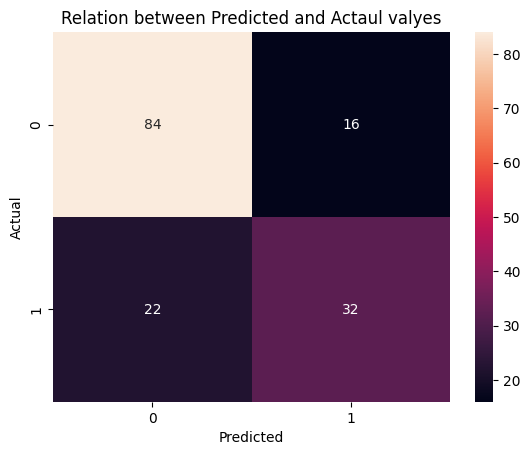

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model=GradientBoostingClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

confusion_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(confusion_matrix,annot=True,fmt='d') #annot used to annotate each cell with numeric value, d means integer format if used 0.2 f then gives floting values
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Relation between Predicted and Actaul valyes")
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid = GridSearchCV(GradientBoostingClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best Score: 0.767173130747701


In [24]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
print(feature_importance)


Glucose                     0.422054
BMI                         0.194099
Age                         0.123504
DiabetesPedigreeFunction    0.121350
Insulin                     0.051264
Pregnancies                 0.044323
BloodPressure               0.028141
SkinThickness               0.015264
dtype: float64


In [25]:
# CHECKING THROUGH SAMPLE DATA
sample = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]

prediction=model.predict(sample)
print("Prediction:",prediction)

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [26]:
#Saving Trained model
import joblib
joblib.dump(model,"diabetes_model.pkl")

['diabetes_model.pkl']

In [27]:
!ls

diabetes_model.pkl  drive  sample_data


In [28]:
! pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.4 MB/s eta 0:00:00


In [29]:
from google.colab import files
files.download("diabetes_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import files
files.download("diabetes_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import files
files.download("Diabetes-Prediction2.ipynb")